### Data Wrangling

Neste desafio, você atuará como analista de dados em uma empresa de vendas, com a missão de prever a receita gerada por vendedores a partir de informações como tempo de experiência, número de vendas e fatores sazonais. O objetivo é aplicar técnicas de regressão para analisar o impacto dessas variáveis e identificar o modelo mais eficiente para previsão de receita.

In [28]:
#Dataset:
#tempo_de_experiencia: Tempo em meses que o vendedor trabalha na empresa.
#numero_de_vendas: Número de vendas realizadas pelo vendedor em um período específico.
#fator_sazonal: Um fator (de 1 a 10) que representa a sazonalidade das vendas (ex: 10 representa alta temporada).
#receita_em_reais: Receita total gerada pelo vendedor.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
data = pd.read_csv('Data/sales_data.csv')

# Display first few rows
print(data.head())

   tempo_de_experiencia  numero_de_vendas  fator_sazonal  receita_em_reais
0                    36                21              5       2639.886941
1                    74                44             10       4707.322227
2                    38                44              4       5910.035131
3                    52                62              6       6130.742546
4                    97                56              2       7516.457681


## EDA

In [30]:
# Display dataset info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_de_experiencia  100 non-null    int64  
 1   numero_de_vendas      100 non-null    int64  
 2   fator_sazonal         100 non-null    int64  
 3   receita_em_reais      100 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [31]:
# Summary statistics
print(data.describe())

       tempo_de_experiencia  numero_de_vendas  fator_sazonal  receita_em_reais
count            100.000000        100.000000     100.000000        100.000000
mean              64.490000         54.490000       5.820000       5112.941924
std               32.397935         25.307201       2.836914       2544.731052
min                1.000000         10.000000       1.000000       1133.363948
25%               38.750000         37.500000       4.000000       2800.660516
50%               64.500000         52.500000       5.000000       4953.770034
75%               93.000000         70.500000       8.000000       7079.500163
max              119.000000        100.000000      10.000000       9941.016458


In [32]:
# Check for missing values
data.isnull().sum()

tempo_de_experiencia    0
numero_de_vendas        0
fator_sazonal           0
receita_em_reais        0
dtype: int64

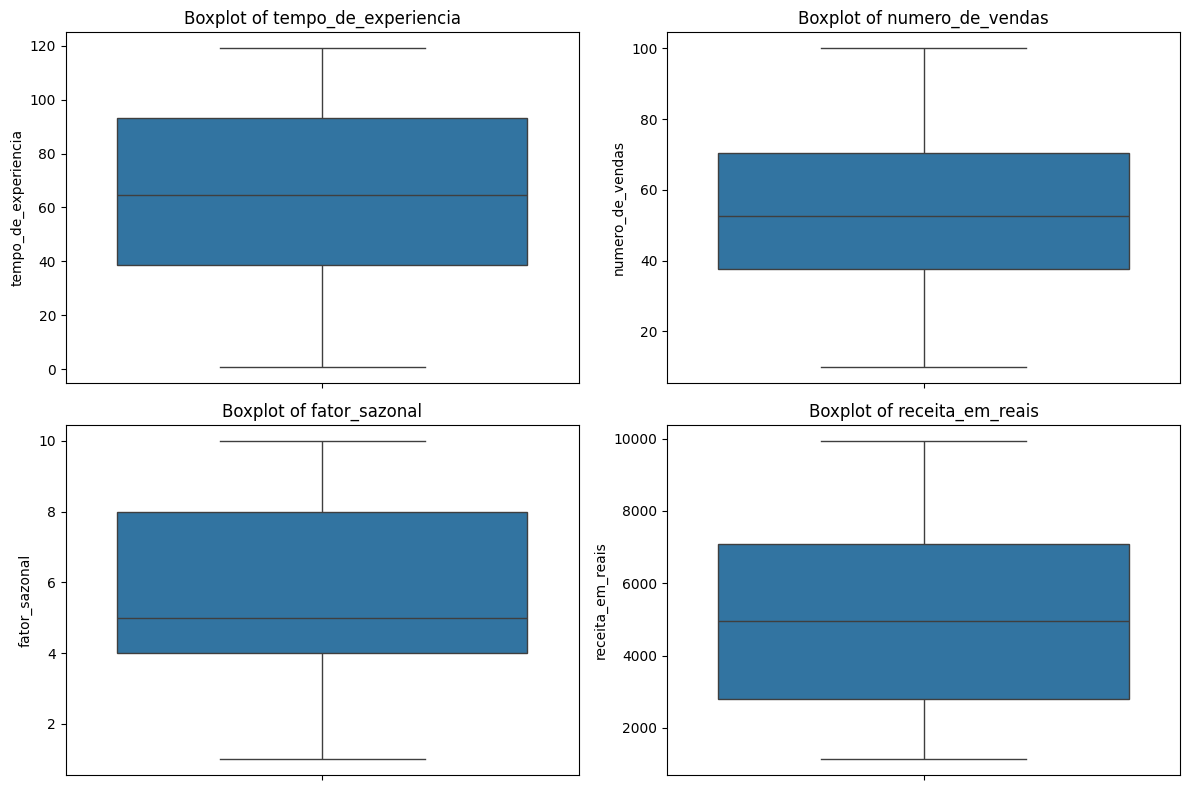

In [33]:
# Check for outliers using boxplots
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

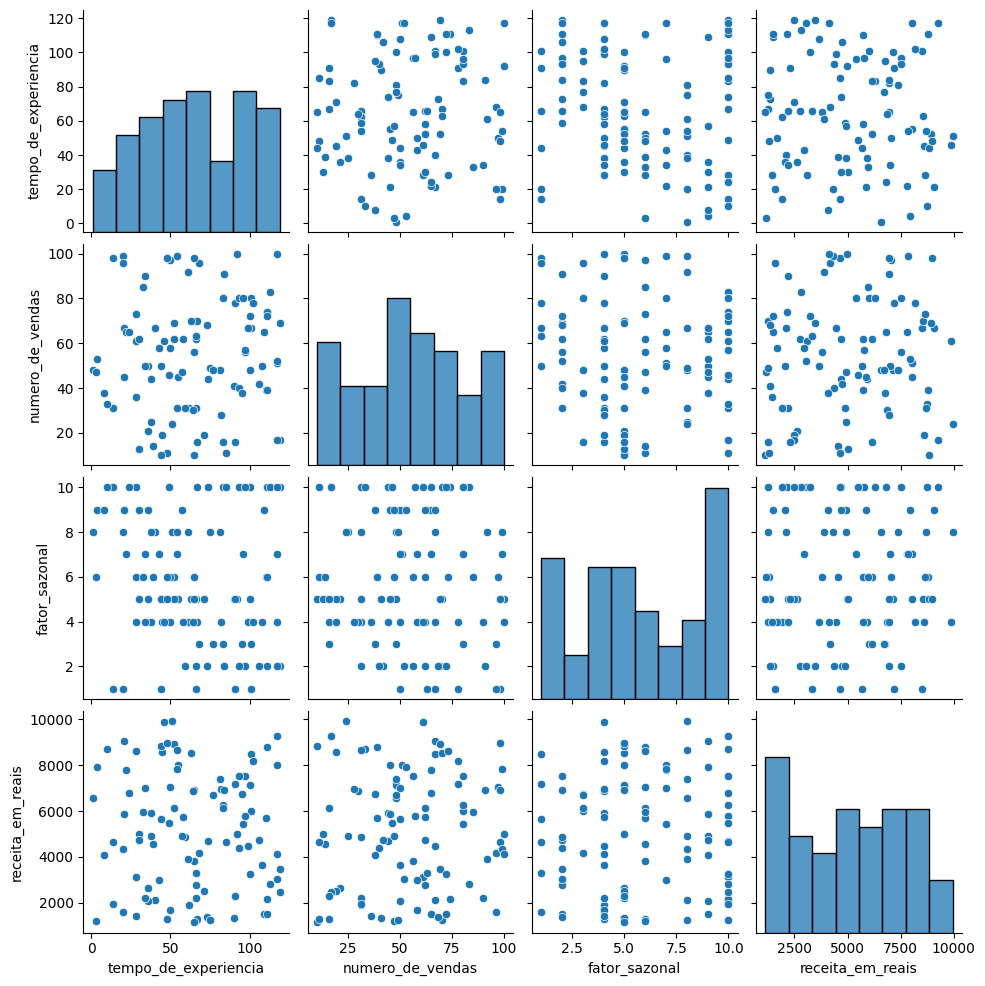

In [34]:
# pairplot to see relationships
sns.pairplot(data)
plt.show()

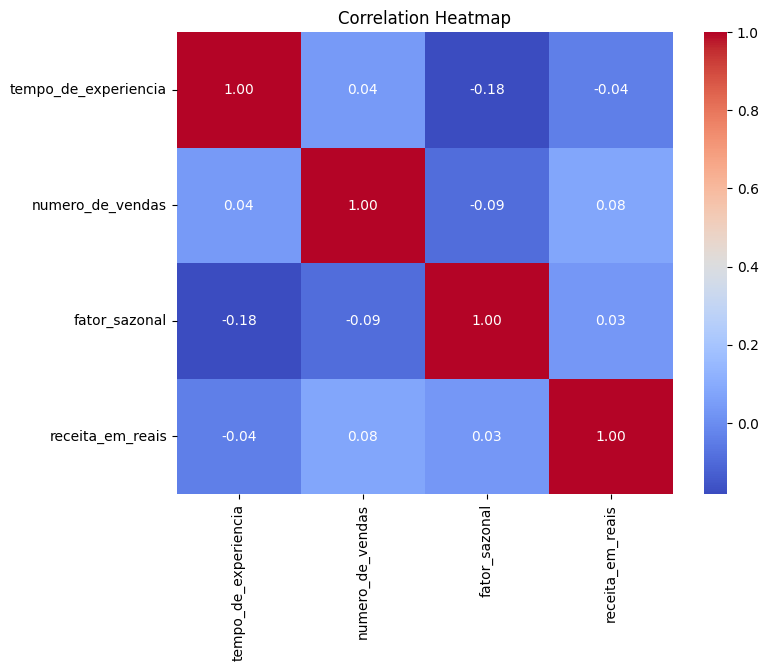

In [35]:
# Check heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [36]:
# More detailed correlation analysis
# Pearson and Spearman data statistic analysis
from scipy.stats import pearsonr, spearmanr

print("PEARSON CORRELATION (Linear relationships):")
for col in data.columns[:-1]:  # All except target
    pearson_corr, pearson_pval = pearsonr(data[col], data['receita_em_reais'])
    if pearson_pval < 0.05:
        significance = "Significant"
    else:
        significance = "Not Significant"
    print(f"{col}: r={pearson_corr:.4f}, p-value={pearson_pval:.4e}, {significance}")
print()
print(90*"-")
print("\nSPEARMAN CORRELATION (Monotonic relationships):")
for col in data.columns[:-1]:
    spearman_corr, spearman_pval = spearmanr(data[col], data['receita_em_reais'])
    if spearman_pval < 0.05:
        significance = "Significant"
    else:
        significance = "Not Significant"
    print(f"{col}: rho={spearman_corr:.4f}, p-value={spearman_pval:.4e}, {significance}")

PEARSON CORRELATION (Linear relationships):
tempo_de_experiencia: r=-0.0428, p-value=6.7262e-01, Not Significant
numero_de_vendas: r=0.0772, p-value=4.4517e-01, Not Significant
fator_sazonal: r=0.0317, p-value=7.5435e-01, Not Significant

------------------------------------------------------------------------------------------

SPEARMAN CORRELATION (Monotonic relationships):
tempo_de_experiencia: rho=-0.0447, p-value=6.5913e-01, Not Significant
numero_de_vendas: rho=0.0769, p-value=4.4671e-01, Not Significant
fator_sazonal: rho=0.0352, p-value=7.2814e-01, Not Significant


## Pre-processing Data


In [37]:
#Data pre-processing to Regression Model
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

In [38]:
# Splitting dataset into features and target and using K-Fold Cross Validation
X = data.drop('receita_em_reais', axis=1)
y = data['receita_em_reais']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
mae_scores = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Pipeline
    transformers = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    # Preprocessing: Scaling features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', transformers, X.columns)]
            )

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)

    # Regression Model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Evaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2_scores.append(r2)
    mae_scores.append(mae)


print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f}")
if np.mean(r2_scores) > 0.7:
    print("The model has a good fit.")
else:
    print("The model may need improvement.")
if np.mean(mae_scores) < y.mean() * 0.1:
    print("The model has acceptable error.")
else:
    print("The model error is high; consider further tuning.")


Average R² Score: -0.2403
Average MAE: 2322.8488
The model may need improvement.
The model error is high; consider further tuning.


Text(0.5, 0, 'Actual Revenue')

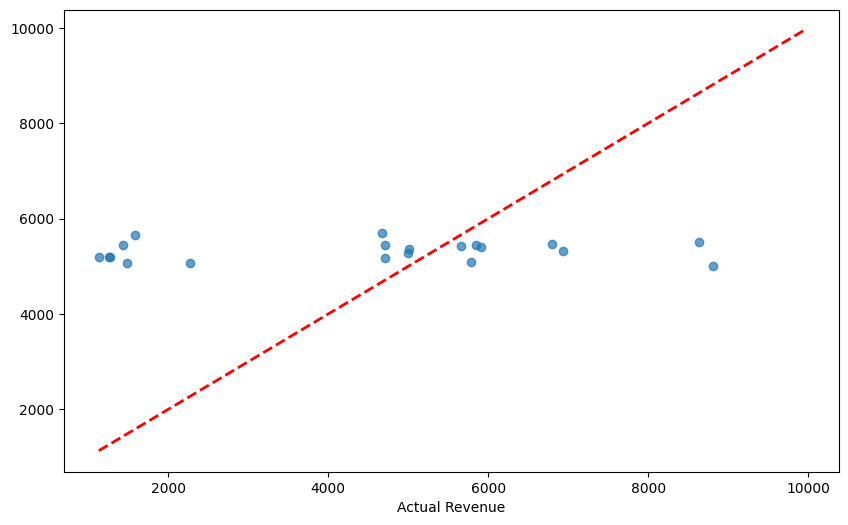

In [39]:
# Plotting a image of comparison between actual and predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue')

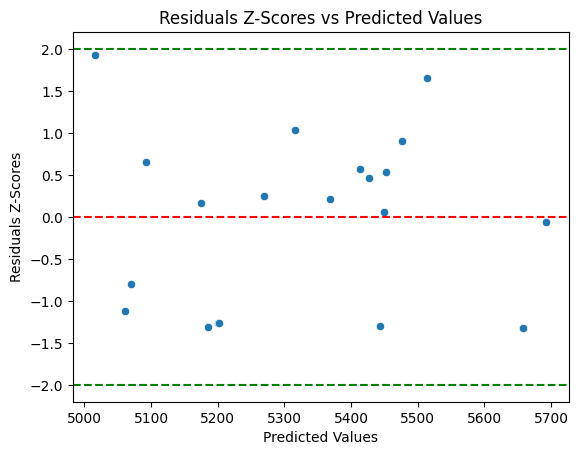

In [40]:
from scipy.stats import zscore
# Residuals
residuals = y_test - y_pred
residuals_std = zscore(residuals)

sns.scatterplot(x=y_pred, y=residuals_std)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2, color='green', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.title('Residuals Z-Scores vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals Z-Scores')
plt.show()

In [41]:
from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors

def interpret_normality_test(stat, p_value, test_name):
    alpha = 0.05
    if p_value > alpha:
        print(f"{test_name}: Statistic={stat:.4f}, p-value={p_value:.4f} -> Fail to reject H0 (Residuals are normally distributed)")
    else:
        print(f"{test_name}: Statistic={stat:.4f}, p-value={p_value:.4f} -> Reject H0 (Residuals are not normally distributed)")

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(residuals)
interpret_normality_test(shapiro_stat, shapiro_p, "Shapiro-Wilk Test")

# Kolmogorov-Smirnov Test
ks_stat, ks_p = kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
interpret_normality_test(ks_stat, ks_p, "Kolmogorov-Smirnov Test")

# Lilliefors Test
lillie_stat, lillie_p = lilliefors(residuals)
interpret_normality_test(lillie_stat, lillie_p, "Lilliefors Test")


Shapiro-Wilk Test: Statistic=0.9135, p-value=0.0743 -> Fail to reject H0 (Residuals are normally distributed)
Kolmogorov-Smirnov Test: Statistic=0.1682, p-value=0.5669 -> Fail to reject H0 (Residuals are normally distributed)
Lilliefors Test: Statistic=0.1620, p-value=0.1894 -> Fail to reject H0 (Residuals are normally distributed)


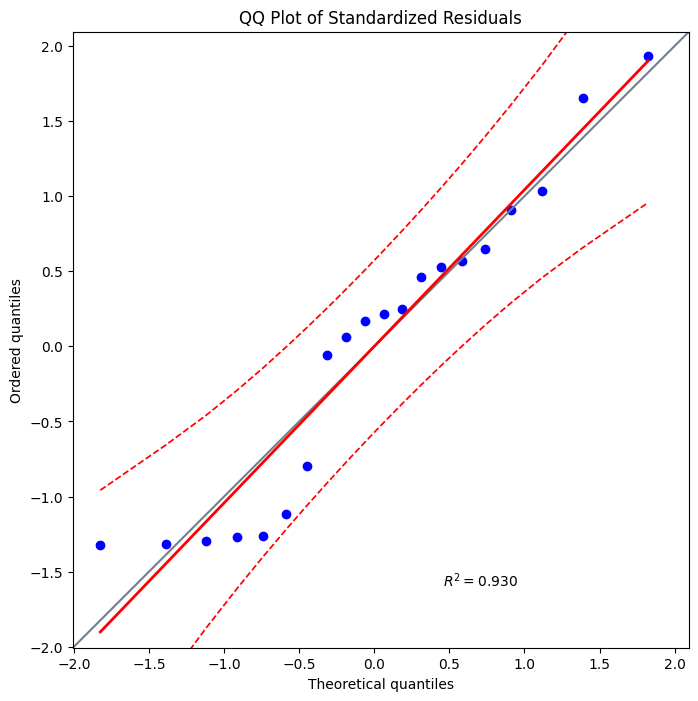

In [42]:
# QQ Plot
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuals_std, dist='norm', confidence=0.95)
plt.title('QQ Plot of Standardized Residuals')
plt.show()

## Insigths


### It is noted that table sales_data there isnt any correlation between variables, noted even at the start, in heatmap.


## Polynomial Regression

In [43]:
# Poly Regression Model

#Polynomial Features to process the Polynomial Options
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
poly_features.feature_names_in_



array(['tempo_de_experiencia', 'numero_de_vendas', 'fator_sazonal'],
      dtype=object)

In [44]:
# All the feature names
poly_features.get_feature_names_out(poly_features.feature_names_in_)

array(['tempo_de_experiencia', 'numero_de_vendas', 'fator_sazonal',
       'tempo_de_experiencia^2', 'tempo_de_experiencia numero_de_vendas',
       'tempo_de_experiencia fator_sazonal', 'numero_de_vendas^2',
       'numero_de_vendas fator_sazonal', 'fator_sazonal^2',
       'tempo_de_experiencia^3',
       'tempo_de_experiencia^2 numero_de_vendas',
       'tempo_de_experiencia^2 fator_sazonal',
       'tempo_de_experiencia numero_de_vendas^2',
       'tempo_de_experiencia numero_de_vendas fator_sazonal',
       'tempo_de_experiencia fator_sazonal^2', 'numero_de_vendas^3',
       'numero_de_vendas^2 fator_sazonal',
       'numero_de_vendas fator_sazonal^2', 'fator_sazonal^3'],
      dtype=object)

In [47]:
# Model training with Polynomial Features
graus = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

rmse_train_result = []
rmse_test_result = []
percentual_rmse_result = []
r2_result = []

kf = KFold(n_splits=5, shuffle=True, random_state=51)


for grau in graus:

    columns = X.columns

    transformers = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', transformers, columns)]
    )

    #feature engineering with polynomial features
    poly_features = PolynomialFeatures(degree=grau, include_bias=False)

    model_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('poly_features', poly_features),
        ('regressor', LinearRegression())
    ])

    rmse_score_fold_train = []
    rmse_score_fold_test = []
    r2_fold_test = []
    residuals = []
    y_pred_tot = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Regression Model
        model_pipe.fit(X_train, y_train)

        # Predictions
        y_train_pred = model_pipe.predict(X_train)
        y_test_pred = model_pipe.predict(X_test)

        rmse_train = mean_absolute_error(y_train, y_train_pred)
        rmse_test = mean_absolute_error(y_test, y_test_pred)
        r2_test = r2_score(y_test, y_test_pred)
        residual =np.array(y_test - y_test_pred)

        rmse_score_fold_train.append(rmse_train)
        rmse_score_fold_test.append(rmse_test)
        r2_fold_test.append(r2_test)
        residuals.append(residual)
        y_pred_tot.append(y_test_pred)
    rmse_train = np.mean(rmse_score_fold_train)
    rmse_test = np.mean(rmse_score_fold_test)
    percentual_rmse = ((rmse_test - rmse_train) / rmse_train) * 100
    residuals = np.array(residuals).reshape(-1)
    y_pred_tot = np.array(y_pred_tot).reshape(-1)
    r2_test = np.mean(r2_fold_test)

    rmse_train_result.append(rmse_train)
    rmse_test_result.append(rmse_test) 
    percentual_rmse_result.append(percentual_rmse)
    r2_result.append(np.mean(r2_fold_test))
    r2_result.append(r2_test)
  


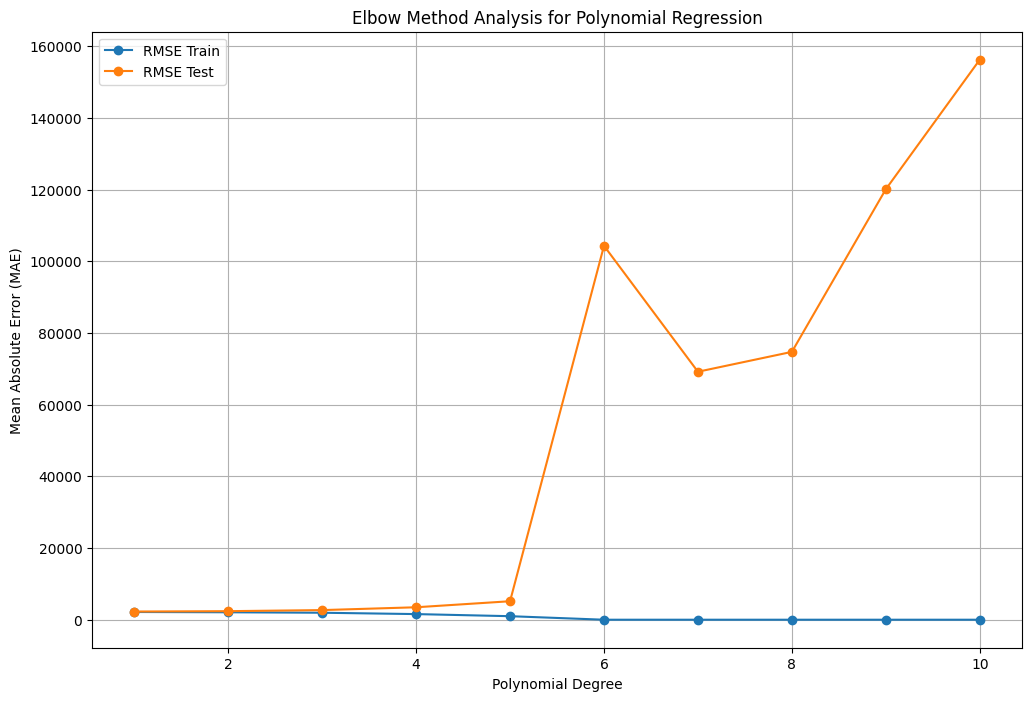

In [59]:
# Elbow Method Analysis

plt.figure(figsize=(12, 8))
plt.plot(graus, rmse_train_result, marker='o', label='RMSE Train')
plt.plot(graus, rmse_test_result, marker='o', label='RMSE Test')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.title('Elbow Method Analysis for Polynomial Regression')
plt.grid(True)
plt.show()